# Homework 1
k-NN classifier for the Iris dataset

## 1. Iris Dataset

In [1]:
# Load the dataset
from sklearn.datasets import load_iris

iris = load_iris()

X, y = iris.data[:, :2], iris.target


In [2]:
# Splitting the data into train/val/test
from sklearn.model_selection import train_test_split

seed = 67

# I first split off a test set
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, train_size=0.85, test_size=0.15, stratify=y, random_state=seed)

# I then split off a validation set
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, train_size=0.7/0.85, test_size=0.15/0.85, stratify=y_train_val, random_state=seed)

# Sizes
n_train, n_val, n_test = len(y_train), len(y_val), len(y_test)
print(f"Training: {n_train}\nValidation: {n_val}\nTesting: {n_test}")

Training: 104
Validation: 23
Testing: 23


## 2. Perform a kNN classification of your dataset for each k in [1, 5, 10, 20, 30, 40, 50, 60, 70]

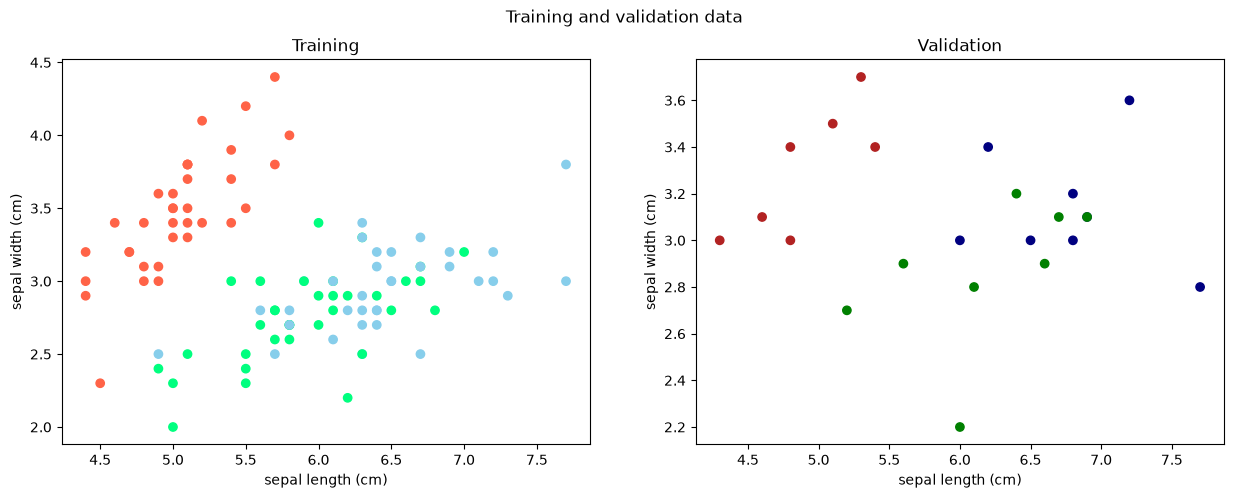

In [3]:
# Plotting my data
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap

cmap_light = ListedColormap(["tomato", "springgreen", "skyblue"])
cmap_bold = ListedColormap(["firebrick", "green", "navy"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Training and validation data")

ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_light)
ax1.set_title("Training")
ax1.set_xlabel(iris.feature_names[0])
ax1.set_ylabel(iris.feature_names[1])

ax2.scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap=cmap_bold)
ax2.set_title("Validation")
ax2.set_xlabel(iris.feature_names[0])
ax2.set_ylabel(iris.feature_names[1])

plt.show()

In [4]:
import numpy as np

# Plotting decision boundaries
def draw_knn_boundaries(knn, ax, h=0.02):

    # Get the x-limits and y-limits of my ax (not the points, the graph)
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    x_axis = np.arange(xmin, xmax, h) # First feature
    y_axis = np.arange(ymin, ymax, h) # Second feature

    x_grid, y_grid = np.meshgrid(x_axis, y_axis) # Generate a 2D grid from the axis

    # Turn the two lists into a grid
    grid = np.column_stack((x_grid.flatten(), y_grid.flatten()))

    # Prediction to create all the points for my decision boundary
    decision_boundaries = knn.predict(grid)

    # Reshaping to prepare it for .pcolormesh
    decision_boundaries = decision_boundaries.reshape(x_grid.shape)

    # Creating the decision boundary image
    ax.pcolormesh(x_grid, y_grid, decision_boundaries, cmap=cmap_light, zorder=1)

    return ax

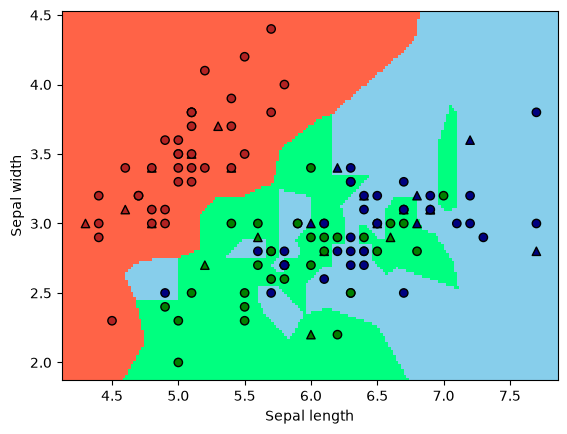

NOTE: Training is circles, validation is traingles.
k=1:
Training accuracy: 0.9326923076923077
Validation accuracy: 0.8695652173913043


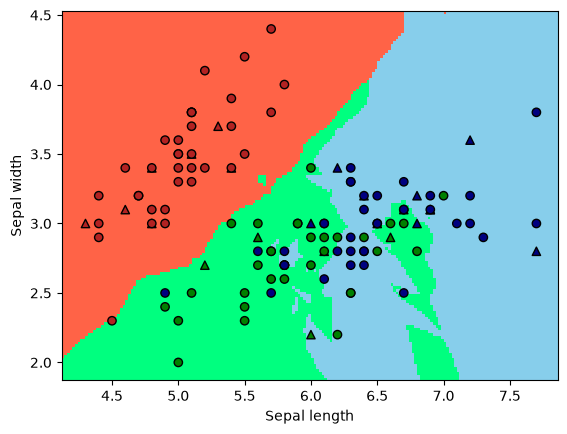

NOTE: Training is circles, validation is traingles.
k=5:
Training accuracy: 0.8173076923076923
Validation accuracy: 0.782608695652174


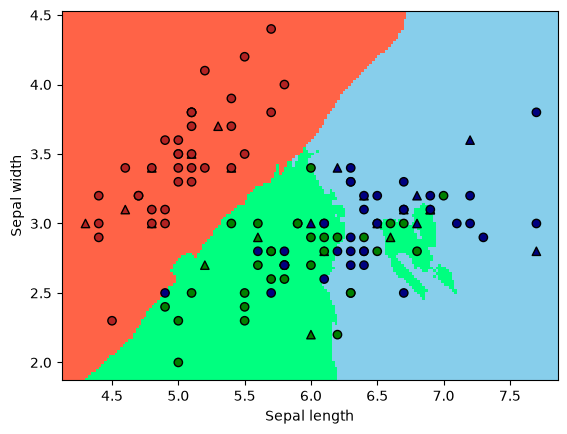

NOTE: Training is circles, validation is traingles.
k=10:
Training accuracy: 0.8269230769230769
Validation accuracy: 0.782608695652174


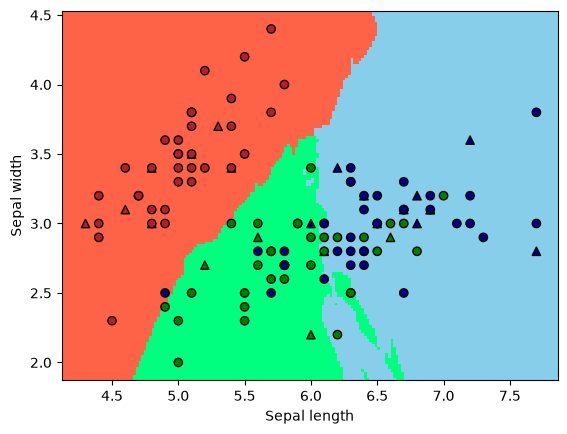

NOTE: Training is circles, validation is traingles.
k=20:
Training accuracy: 0.7980769230769231
Validation accuracy: 0.7391304347826086


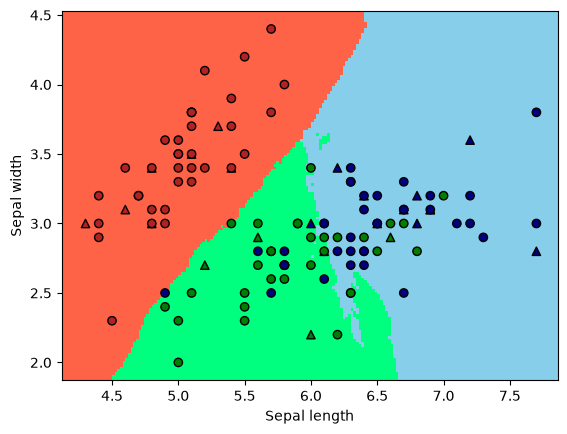

NOTE: Training is circles, validation is traingles.
k=30:
Training accuracy: 0.7980769230769231
Validation accuracy: 0.782608695652174


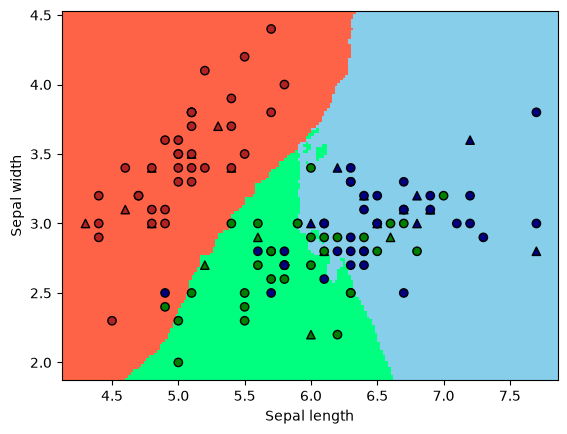

NOTE: Training is circles, validation is traingles.
k=40:
Training accuracy: 0.7980769230769231
Validation accuracy: 0.8260869565217391


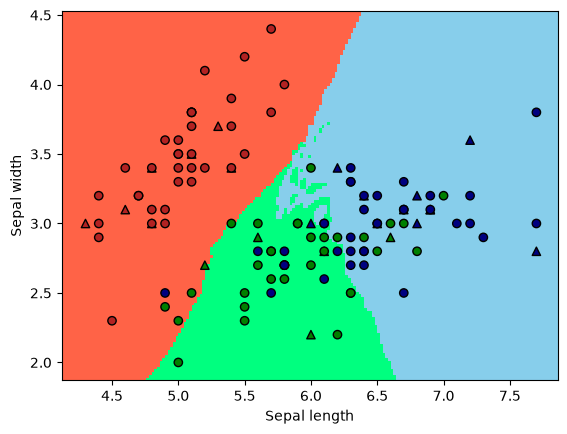

NOTE: Training is circles, validation is traingles.
k=50:
Training accuracy: 0.7596153846153846
Validation accuracy: 0.7391304347826086


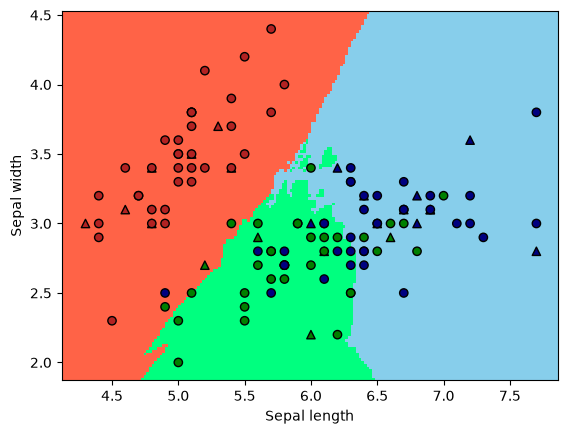

NOTE: Training is circles, validation is traingles.
k=60:
Training accuracy: 0.7692307692307693
Validation accuracy: 0.7391304347826086


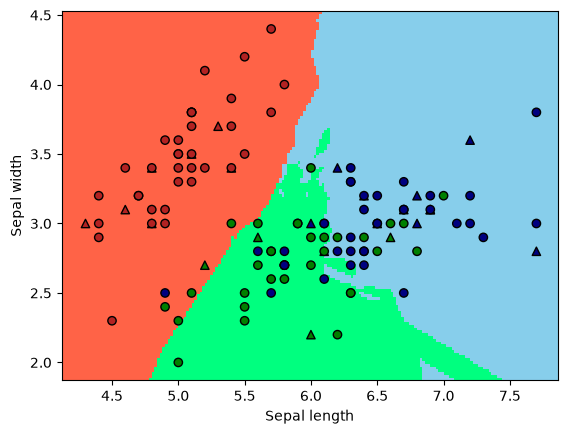

NOTE: Training is circles, validation is traingles.
k=70:
Training accuracy: 0.75
Validation accuracy: 0.6956521739130435
{1: (0.9326923076923077, 0.8695652173913043), 5: (0.8173076923076923, 0.782608695652174), 10: (0.8269230769230769, 0.782608695652174), 20: (0.7980769230769231, 0.7391304347826086), 30: (0.7980769230769231, 0.782608695652174), 40: (0.7980769230769231, 0.8260869565217391), 50: (0.7596153846153846, 0.7391304347826086), 60: (0.7692307692307693, 0.7391304347826086), 70: (0.75, 0.6956521739130435)}


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

ks = [1, 5, 10, 20, 30, 40, 50, 60, 70]
accuracies = {}

for k in ks:
    fig, ax = plt.subplots()

    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold, edgecolor="k", zorder=3)
    ax.scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap=cmap_bold, edgecolor="k", zorder=2, marker="^")

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    draw_knn_boundaries(knn, ax)
    ax.set_xlabel("Sepal length")
    ax.set_ylabel("Sepal width")

    plt.show()

    train_predictions = knn.predict(X_train)
    val_predictions = knn.predict(X_val)

    training_accuracy = accuracy_score(y_train, train_predictions)
    validation_accuracy = accuracy_score(y_val, val_predictions)

    accuracies[k] = (training_accuracy, validation_accuracy)

    print("NOTE: Training is circles, validation is traingles.")
    print(f"k={k}:\nTraining accuracy: {training_accuracy}\nValidation accuracy: {validation_accuracy}")

print(accuracies)

In [6]:
best_k = max(accuracies, key=lambda k: accuracies[k][1])

print(f"The best k is {best_k}!")

The best k is 1!


In [7]:
# Creating my best model
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [8]:
# Testing my best model on the testing set
testing_predictions = best_model.predict(X_test)
testing_accuracy = accuracy_score(y_test, testing_predictions)
print(testing_accuracy)

0.8695652173913043


## 3. Interpretation

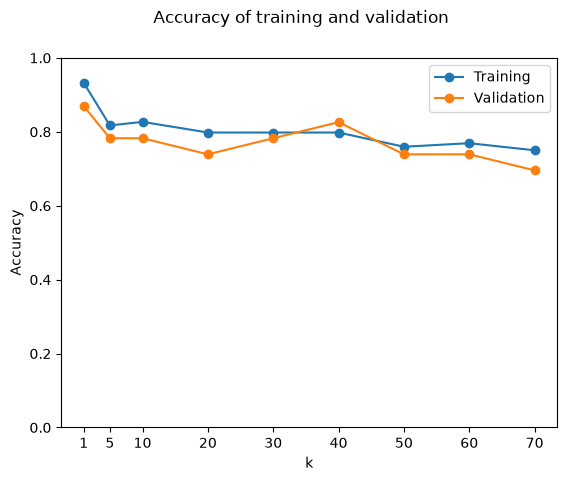

In [9]:
fig, ax = plt.subplots()
fig.suptitle("Accuracy of training and validation")

# Getting all my accuracies in lists
training_accuracies = [accuracies[k][0] for k in ks]
validation_accuracies = [accuracies[k][1] for k in ks]

ax.plot(ks, training_accuracies, marker="o", label="Training")
ax.plot(ks, validation_accuracies, marker="o", label="Validation")
ax.set_ylim(0, 1)
ax.set_xticks(ks)
ax.set_xlabel("k")
ax.set_ylabel("Accuracy")
ax.legend()

plt.show()

From your observations, for which values of k does kNN overfit/underfit?

From my observations I think the model is overfitting for small values of k, especially for k=1 and k=5. The biggest giveaway is the islands of one color in the sea of another color. This shows me that the model is memorizing the location of one specific datapoint, not generalizing. I think the model is underfitting for large values of k, especially for k=50, k=60 and k=70. I say this because both the training and validation accuracy drops. This shows that the model is just getting too general to tell us anything interesting.

For k=1, k-NN training accuracy should be equal to 1 (100% correct predictions). Explain why this is not the case here.

This is not the case here because we are working with only two features. There are probably flowers of different species in the dataset which have the same measurements, these will be impossible for our k-NN to distinguish. It will therefore be wrong on these examples. A fix would be to use all the features in the dataset, this could give the model important information which it could use to distinguish the species in these cases.

## Final thoughts
Kinda sucks that k=1 does the best on the validation set since it is clearly overfitting. k=40 also looks pretty good and it is not overfitting.